In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats

In [3]:
import numpy as np
import h5py
import healpy as hp
import multiprocessing as mp

class CosmoGridLoader:
    def __init__(self, data_path="/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0000", nside_target=512):
        """
        data_path  : base directory containing CosmoGRID HDF5 files.
        nside_target: target Healpix resolution (CosmoGRID maps are at nside=512).
        """
        self.data_path = data_path
        self.nside_target = nside_target  # CosmoGRID maps are provided at nside=512

    def get_beam(self, theta, lmax):
        """
        Compute the beam transfer function for a top-hat filter.
        
        theta: smoothing scale in arcmin.
        lmax : maximum multipole.
        """
        def top_hat(b, radius):
            # Returns a top-hat filter; adjust normalization if needed.
            return np.where(np.abs(b) <= radius, 1/(np.cos(radius) - 1)/(-2*np.pi), 0)
        
        t = theta * np.pi / (60 * 180)  # convert arcmin to radians
        b = np.linspace(0.0, t * 1.2, 10000)
        bw = top_hat(b, t)
        beam = hp.sphtfunc.beam2bl(bw, b, lmax)
        return beam

    def smooth_map(self, args):
        """
        Smooth the input kappa map using the beam corresponding to the given theta.
        
        args: tuple (theta, lmax, kappa_map, nside)
        """
        theta, lmax, kappa_map, nside = args
        beam = self.get_beam(theta, lmax)
        almkappa = hp.sphtfunc.map2alm(kappa_map)
        kappa_smooth = hp.sphtfunc.alm2map(hp.sphtfunc.almxfl(almkappa, beam), nside)
        return kappa_smooth

    def load_cosmogrid_map(self, id_zbin, perm_index=0):
        """
        Load the base κ map from the CosmoGRID HDF5 file.
        
        id_zbin   : redshift bin index (e.g., 3 for the fourth bin)
        perm_index: simulation permutation index.
        """
        # For simplicity we use the "nobaryons" file; update if needed.
        file_path = f"{self.data_path}/projected_probes_maps_nobaryons512.h5"
        print(f"Loading CosmoGRID map from: {file_path}")
        with h5py.File(file_path, 'r') as f:
            # The dataset is assumed to be stored as 'kg/stage3_lensing{id_zbin+1}'
            dataset_name = f"kg/stage3_lensing{id_zbin+1}"
            print(f"Accessing dataset: {dataset_name}")
            kappa = np.array(f[dataset_name])
        # Ensure the map is at the target nside (though it should already be 512)
        kappa_target = hp.ud_grade(kappa, self.nside_target)
        return kappa_target

    def run_loader(self, theta, id_zbin=3, perm_index=0, nprocess=1):
        """
        Mimics TakahashiLoader.run_loader:
          - Loads the base CosmoGRID κ map.
          - Smooths it twice: once with θ and once with 2θ.
          - Computes the variance of the difference between the two smoothed maps.
          - For simplicity, assumes the source redshift is the mean n(z) (here set as a default).
        
        Parameters:
          theta     : primary smoothing scale in arcmin.
          id_zbin   : redshift bin index.
          perm_index: permutation index (to choose which simulation realization to load).
          nprocess  : number of processes to use for smoothing.
        
        Returns:
          variance  : variance of (kappa_smooth2 - kappa_smooth1).
          kappa_smooth1: map smoothed with θ.
          kappa_smooth2: map smoothed with 2θ.
        """
        # Load the base map (at nside=512)
        kappa = self.load_cosmogrid_map(id_zbin, perm_index)
        nside_target = self.nside_target
        lmax = nside_target * 3 - 1  # same as in Takahashi
        
        # Setup arguments for the two smoothing scales
        args1 = (theta, lmax, kappa, nside_target)
        args2 = (theta * 2, lmax, kappa, nside_target)
        
        # Use parallel processing if requested
        if nprocess > 1:
            with mp.Pool(processes=nprocess) as pool:
                kappa_smooth1, kappa_smooth2 = pool.map(self.smooth_map, [args1, args2])
        else:
            kappa_smooth1 = self.smooth_map(args1)
            kappa_smooth2 = self.smooth_map(args2)
            
        variance = np.var(kappa_smooth2 - kappa_smooth1)
        
        # For now, we take the mean of n(z) as our source redshift.
        # (Update this if you later have the actual n(z) distribution.)
        source_z = 0.9416
        print("Assumed source redshift (mean n(z)):", source_z)
        
        return variance, kappa_smooth1, kappa_smooth2

In [ ]:
# param_file = "/Users/vilasini/Documents/WALE/data/selected_params_halofit_unique.npy"
# param_table = np.load(param_file)
# param_table


Now computing for the CosmoGRID simulation..
Loading CosmoGRID map from: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_nobaryons512.h5
Accessing dataset: kg/stage3_lensing4


Assumed source redshift (mean n(z)): 0.9416
Variance from CosmoGRID simulation: 5.9957627584759e-06


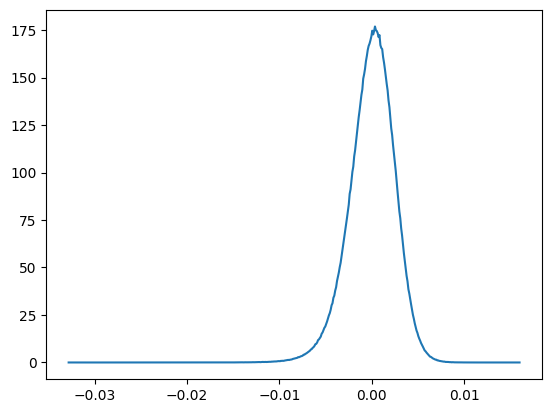

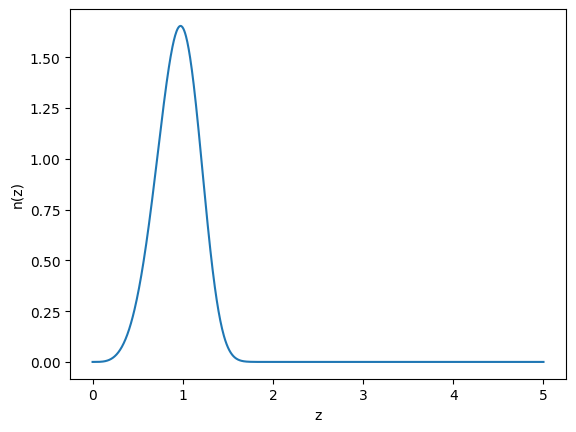

Using n(z) file: /home/tersenov/CosmoGridV1/stage3_forecast/nz/nz_stage3_4.txt

Initialised Cosmology:
  h = 0.6736, Oc = 0.2107, Ob = 0.0493, w = -1.0, wa = 0.0, sigma8 = 0.84
  k-range: [0.001, 0.9] with step dk = 0.005

Initialising WALE with the following parameters:
   Initialised Variables:
      Source redshift: from nz file
      Number of planes: 20
      Angular scale theta1 (radians): 0.005817764173314432, arcmin: 20.0
      Variability: disabled
 
   Variance module initialized...
  Computing σ²_κ at θ=20.00 arcmin using ℓ in [2.0, 20000.0]
  The ldt variance is: 5.974107387383363e-06
  The perturbation theory variance is: 6.049645520385831e-06
   The CosmoGRID variance is: 5.9957627584759e-06
   The recalibration factor is: 0.9963882208211251
   Finding critical points (optimized)...
       Setting ngrid = 50. Increase for accuracy; runtime ~ O(ngrid^2).
       Smallest positive / largest negative: 1182.7410414649462 / -685.3324591285325
   The variance from PDF is:  5.994

(-0.1, 0.3066320793478528)

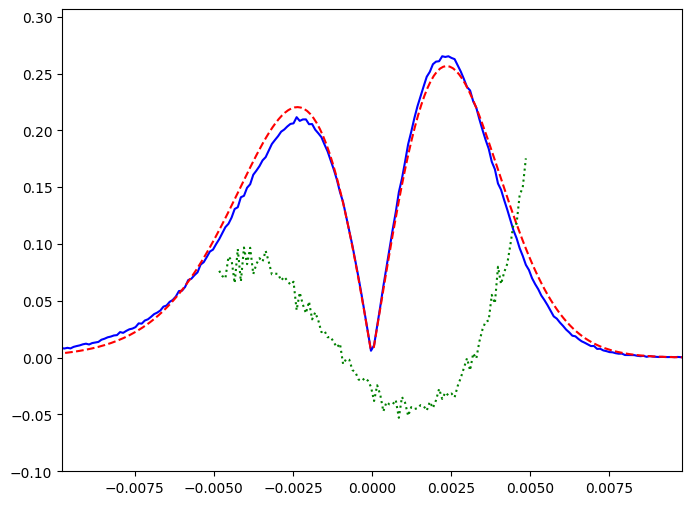

In [ ]:
fid_map_path = "/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_nobaryons512.h5"
id_zbin = 3  # Corresponds to the third redshift bin
nz_file = f"/home/tersenov/CosmoGridV1/stage3_forecast/nz/nz_stage3_{id_zbin+1}.txt"

# Flag to load CosmoGRID simulation data
load_cosmogrid = True
theta1_input = 20.0  # Smoothing scale in arcmin
if load_cosmogrid:
    print("\nNow computing for the CosmoGRID simulation..")
    
    # CosmoGRID maps are at nside=512, and we use the same smoothing logic.
    loader = CosmoGridLoader(nside_target=512)
    
    # 'theta' is your smoothing scale in arcmin; id_zbin is the desired redshift bin.
    variance_cosmogrid, kmap1, kmap2 = loader.run_loader(theta=theta1_input, id_zbin=id_zbin, perm_index=0, nprocess=1)
    
    # Compute the mass map difference (smoothed with 2θ vs. θ)
    k_massmap_simulation = kmap2 - kmap1
    
    # Calculate the PDF of the simulation
    pdf_simulation, bin_edges = np.histogram(k_massmap_simulation, bins=500, density=True)
    kappa_sim = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    print("Variance from CosmoGRID simulation:", variance_cosmogrid)

    plt.plot(kappa_sim, pdf_simulation)

# --- Cosmology parameters ---
h = 0.6736
Ob = 0.0493
w = -1.0
wa = 0.0
sigma8 = 0.84
Om = 2.6e-01
Oc = Om - Ob
ns = 0.9649

plt.figure()
plt.plot(*np.loadtxt(nz_file).T)
plt.xlabel("z")
plt.ylabel("n(z)")
plt.show()
print(f"Using n(z) file: {nz_file}")
theta1 = theta1_input  # in arcmin
filter_type = 'tophat'
snr = np.linspace(-3, 3, 300)

variables = InitialiseVariables(
h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
dk=0.005, kmin=1e-3, kmax=.9,
nz_file=nz_file, variability=False,
theta1=theta1, nplanes=20, ns=ns )

# Compute sigma^2 maps
variance = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
variables.sigmasq_map = np.sum(
    variables.dchi * (variables.lensingweights ** 2) * np.array([
        variance.get_sig_slice(z, chi * variables.theta1_radian, chi * variables.theta2_radian)
        for z, chi in zip(variables.redshifts, variables.chis)
    ])
)

# Theory (perturbation) sigma^2
theory_sigmasq = compute_sigma_kappa_squared(
    theta1, variables.chis, variables.lensingweights,
    variables.redshifts, variables.cosmo.k, variables.cosmo.pnl,
    filter_type=filter_type, h=h
)

variables.recal_value = variables.sigmasq_map / (variance_cosmogrid)
    
print(f"  The ldt variance is: {variables.sigmasq_map}")
print(f"  The perturbation theory variance is: {theory_sigmasq}") 
print(f"   The CosmoGRID variance is: {variance_cosmogrid}")
print(f"   The recalibration factor is: {variables.recal_value}")
        
# Critical points and lambdas
smallest_positive, largest_negative = find_critical_points_for_cosmo(
    variables, variance, ngrid_critical=50, plot=False, min_z=0, max_z=5
)
if smallest_positive and largest_negative is not None:
    variables.lambdas = np.linspace(largest_negative, smallest_positive, 20)
    
# Compute PDF and L1
computed_PDF = computePDF(variables, variance, plot_scgf=False)
pdf_vals, kappa_vals = computed_PDF.pdf_values, computed_PDF.kappa_values
norm_kappa = kappa_vals / np.sqrt(theory_sigmasq)
prediction_pdf = CubicSpline(norm_kappa, pdf_vals)(snr)
prediction_l1 = CubicSpline(norm_kappa, np.abs(kappa_vals) * pdf_vals)(snr)

# Store results
pred_stats = get_moments(kappa_vals, pdf_vals)            
print(f"  predstats: mean: {pred_stats[0]}, variance: {pred_stats[1]}, s3: {pred_stats[2]:.3f}, kurtosis: {pred_stats[3]:.3f}, norm: {pred_stats[4]:.3f}")
sim_stats = get_moments(kappa_sim, pdf_simulation)
print(f"  simstats: mean: {sim_stats[0]}, variance: {sim_stats[1]}, s3: {sim_stats[2]:.3f}, kurtosis: {sim_stats[3]:.3f}, norm: {sim_stats[4]:.3f}")
    
# --- Plotting ---
plt.figure(figsize=(8,6))
plt.plot(kappa_sim, pdf_simulation*np.abs(kappa_sim), label='CosmoGRID Simulation', color='blue')
plt.plot(kappa_vals, pdf_vals*np.abs(kappa_vals), label='Perturbation Theory', color='red', linestyle='--')
residual = (CubicSpline(kappa_vals, pdf_vals)(kappa_sim) - pdf_simulation) / (pdf_simulation + 1e-12)
mask = np.where((kappa_sim >= -2*np.std(k_massmap_simulation)) & (kappa_sim <= 2*np.std(k_massmap_simulation)) )
plt.plot(kappa_sim[mask], residual[mask], label='Residual', color='green', linestyle=':')
plt.xlim(-4*np.std(k_massmap_simulation), 4*np.std(k_massmap_simulation))
plt.ylim(-0.1, np.max(prediction_l1)+0.05)

In [3]:
variances_run = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_variances_halofit_nobaryons_bin4.npy')
l1_runs = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_halofit_nobaryons_bin4.npy')
kappa_run = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_kappas_halofit_nobaryons_bin4.npy')

In [4]:
variances_run.shape, l1_runs.shape, kappa_run.shape

((1299,), (1299, 500), (1299, 500))

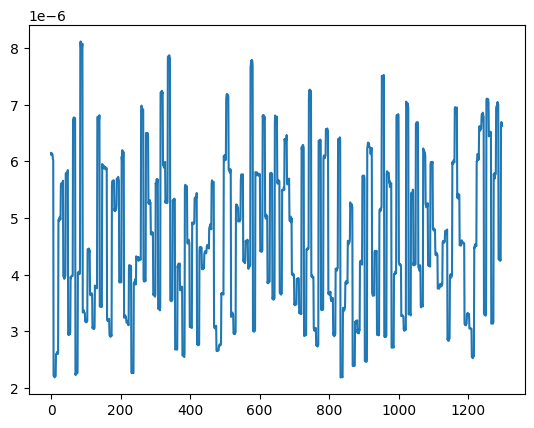

In [5]:
plt.plot(variances_run)

(0.0, 0.27)

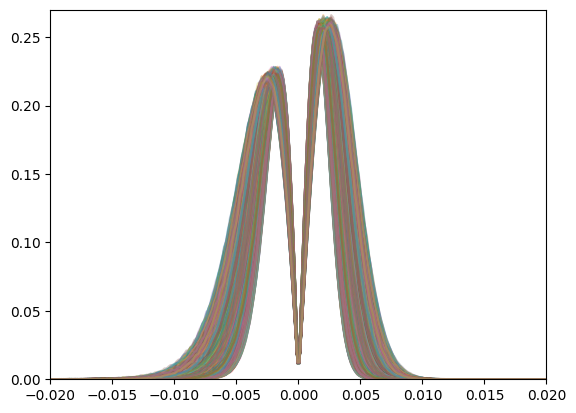

In [6]:
for i in range(l1_runs.shape[0]):
    plt.plot(kappa_run[i], l1_runs[i], alpha=0.3)

plt.xlim(-0.02, 0.02)
plt.ylim(0, 0.27)

(-0.05, 0.3)

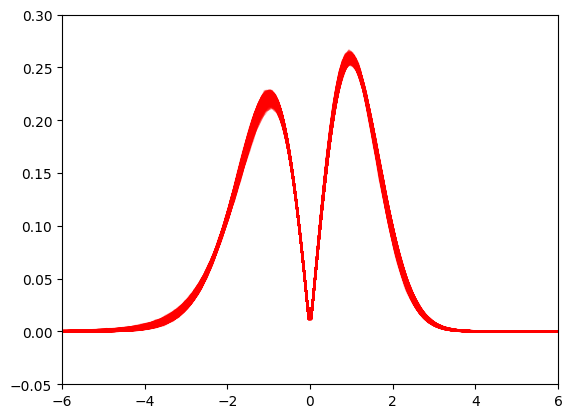

In [7]:
for i in range(l1_runs.shape[0]):
    plt.plot(kappa_run[i]/np.sqrt(variances_run[i]), l1_runs[i], alpha=0.3, color='red')
plt.xlim(-6, 6)
plt.ylim(-0.05, 0.30)

In [27]:
fid_variances = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_variances_fiducial_nobaryons_bin4.npy')
fid_l1s = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin4.npy')
fid_kappas = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_kappas_fiducial_nobaryons_bin4.npy')

In [28]:
fid_kappas.shape, fid_l1s.shape, fid_variances.shape

((200, 500), (200, 500), (200,))

In [29]:
# take average over

(-6.0, 6.0)

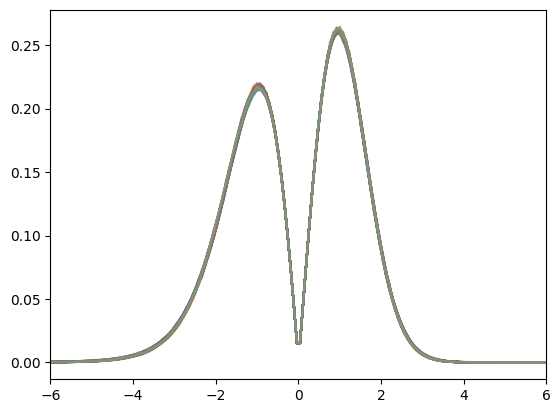

In [30]:
for i in range(fid_l1s.shape[0]):
    plt.plot(fid_kappas[i]/np.sqrt(fid_variances[i]), fid_l1s[i], alpha=0.3)

plt.xlim(-6, 6)

(-6.0, 6.0)

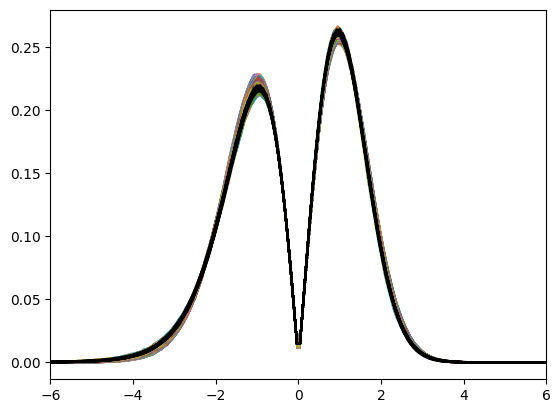

In [31]:
for i in range(l1_runs.shape[0]):
    plt.plot(kappa_run[i]/np.sqrt(variances_run[i]), l1_runs[i], alpha=0.8)
for i in range(fid_l1s.shape[0]):
    plt.plot(fid_kappas[i]/np.sqrt(fid_variances[i]), fid_l1s[i], alpha=0.3, color='k')
plt.xlim(-6, 6)

(-0.02, 0.02)

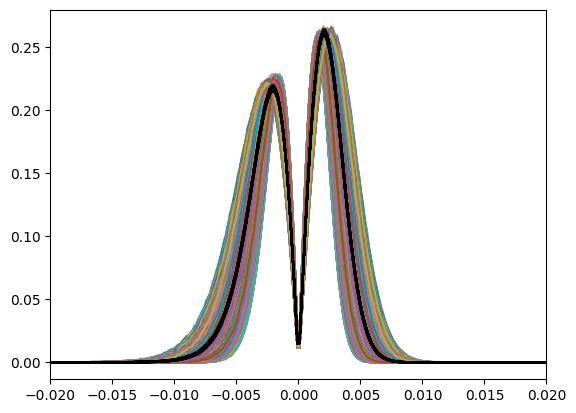

In [32]:
for i in range(l1_runs.shape[0]):
    plt.plot(kappa_run[i], l1_runs[i], alpha=0.8)
for i in range(fid_l1s.shape[0]):
    plt.plot(fid_kappas[i], fid_l1s[i], alpha=0.3, color='k')
plt.xlim(-0.02, 0.02)

### theta=20

In [9]:
variances_run_theta20 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_variances_halofit_nobaryons_bin4_theta20.0.npy')
l1_runs_theta20 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_halofit_nobaryons_bin4_theta20.0.npy')
kappa_run_theta20 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_kappas_halofit_nobaryons_bin4_theta20.0.npy')

In [10]:
variances_run_theta20.shape, l1_runs.shape, kappa_run.shape

((1299,), (1299, 500), (1299, 500))

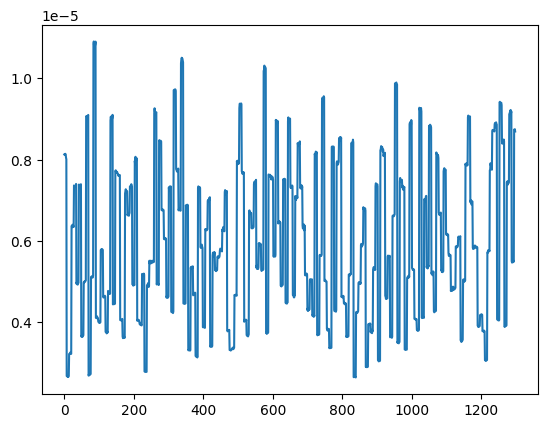

In [11]:
plt.plot(variances_run_theta20)

(0.0, 0.27)

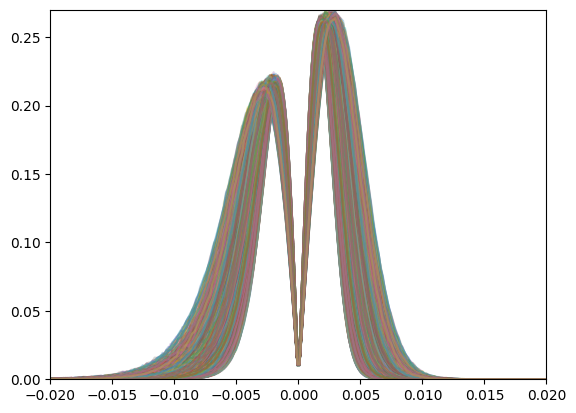

In [12]:
for i in range(l1_runs_theta20.shape[0]):
    plt.plot(kappa_run_theta20[i], l1_runs_theta20[i], alpha=0.3)

plt.xlim(-0.02, 0.02)
plt.ylim(0, 0.27)

(-0.05, 0.3)

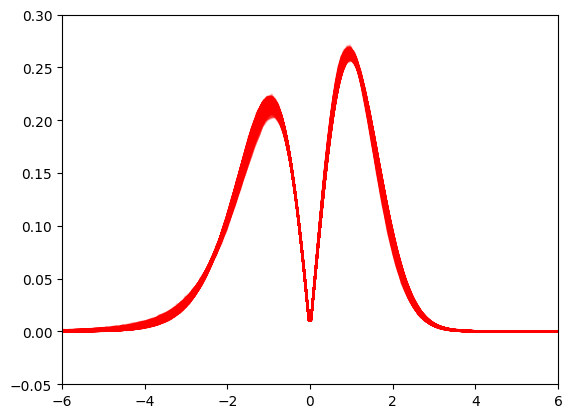

In [13]:
for i in range(l1_runs_theta20.shape[0]):
    plt.plot(kappa_run_theta20[i]/np.sqrt(variances_run_theta20[i]), l1_runs_theta20[i], alpha=0.3, color='red')
plt.xlim(-6, 6)
plt.ylim(-0.05, 0.30)

### theta=10

In [4]:
variances_run_theta10 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_variances_halofit_nobaryons_bin4_theta10.0.npy')
l1_runs_theta10 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_halofit_nobaryons_bin4_theta10.0.npy')
kappa_run_theta10 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_kappas_halofit_nobaryons_bin4_theta10.0.npy')

In [8]:
fid_variances_theta10 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_variances_fiducial_nobaryons_bin4_theta10.0.npy')
fid_l1s_theta10 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin4_theta10.0.npy')
fid_kappas_theta10 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_kappas_fiducial_nobaryons_bin4_theta10.0.npy')

In [9]:
variances_run_theta10.shape, l1_runs_theta10.shape, kappa_run_theta10.shape, fid_variances_theta10.shape, fid_l1s_theta10.shape, fid_kappas_theta10.shape

((1299,), (1299, 500), (1299, 500), (200,), (200, 500), (200, 500))

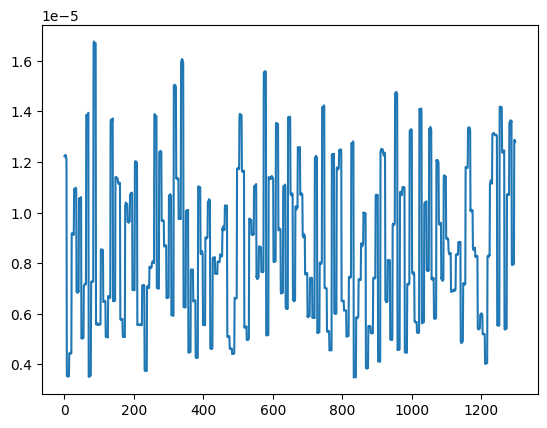

In [16]:
plt.plot(variances_run_theta10)

(0.0, 0.27)

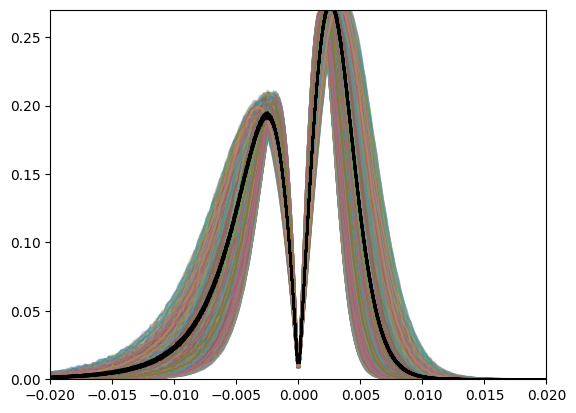

In [10]:
for i in range(l1_runs_theta10.shape[0]):
    plt.plot(kappa_run_theta10[i], l1_runs_theta10[i], alpha=0.3)
for i in range(fid_l1s_theta10.shape[0]):
    plt.plot(fid_kappas_theta10[i], fid_l1s_theta10[i], alpha=0.3, color='k')

plt.xlim(-0.02, 0.02)
plt.ylim(0, 0.27)

(-0.05, 0.3)

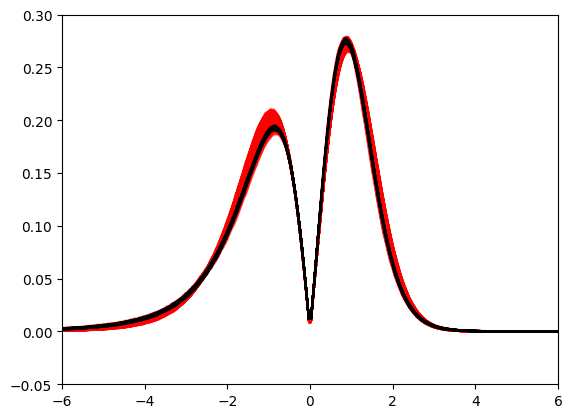

In [11]:
for i in range(l1_runs_theta10.shape[0]):
    plt.plot(kappa_run_theta10[i]/np.sqrt(variances_run_theta10[i]), l1_runs_theta10[i], alpha=0.3, color='red')
for i in range(fid_l1s_theta10.shape[0]):
    plt.plot(fid_kappas_theta10[i]/np.sqrt(fid_variances_theta10[i]), fid_l1s_theta10[i], alpha=0.3, color='k')
plt.xlim(-6, 6)
plt.ylim(-0.05, 0.30)

In [12]:
# load parameters corresponding to the runs
params = np.load('/home/tersenov/software/bar_impact/data/selected_params_halofit.npy')

In [14]:
# the first 2 parameters are Om and sigma8
# calculate S8 = sigma8 * (Om/0.3)^0.5 for each run
s8_values = params[:, 1] * (params[:, 0] / 0.3) ** 0.5
s8_values.shape

(1299,)

(-0.02, 0.02)

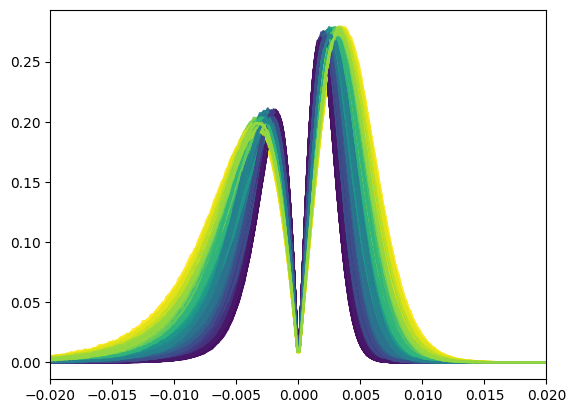

In [17]:
# plot the l1_runs_theta10 color-coded by s8_values
import matplotlib.pyplot as plt
for i in range(l1_runs_theta10.shape[0]):
    plt.plot(kappa_run_theta10[i], l1_runs_theta10[i], alpha=0.8, color=plt.cm.viridis((s8_values[i]-np.min(s8_values))/(np.max(s8_values)-np.min(s8_values))))
plt.xlim(-0.02, 0.02)

In [19]:
# find the min and max values for all the parameters
param_mins = np.min(params, axis=0)
param_maxs = np.max(params, axis=0)
param_mins, param_maxs

print('Omega_m range:', param_mins[0], param_maxs[0])
print('sigma8 range:', param_mins[1], param_maxs[1])
print('w0 range:', param_mins[2], param_maxs[2])
print('H0 range:', param_mins[3], param_maxs[3])
print('ns range:', param_mins[4], param_maxs[4])
print('Omega_b range:', param_mins[5], param_maxs[5])

Omega_m range: 0.211204528809 0.399859619141
sigma8 range: 0.611120605469 0.89853515625
w0 range: -1.148611850739 -0.851101341248
H0 range: 64.544921875 81.4375
ns range: 0.87341796875 1.045439453125
Omega_b range: 0.032233886719 0.054697265625
